In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mlp_dataset.csv')
df.head()

,Product,Issue,Company,State,Complaint_length,Word_count,month,day_of_week,hour,Risk
0,Checking or savings account,Managing an account,AMERIS BANCORP,GA,1002,188,1,Thursday,2,0
1,Debt collection,Attempts to collect debt not owed,"Kriya Capital, LLC",GA,2039,332,1,Thursday,3,1
2,Debt collection,Took or threatened to take negative or legal a...,Rosebud Economic Development Corporation,TX,530,85,1,Thursday,0,1
3,Debt collection,Took or threatened to take negative or legal a...,"Portfolio Recovery Associates, LLC",TX,430,74,1,Thursday,0,0
4,Credit card,Other,"EQUIFAX, INC.",IL,182,31,1,Thursday,0,1


In [3]:
df.shape

(53898, 10)

В рассматриваемом датасете мы имеем 53 898 жалобы и 10 признаков

Название признаков

In [4]:
df.columns

Index(['Product', 'Issue', 'Company', 'State', 'Complaint_length',
       'Word_count', 'month', 'day_of_week', 'hour', 'Risk'],
      dtype='object')

1. Разделим признаки на три группы: категориальные, числовые и целевая переменная.

In [5]:
cat_cols = ['Product', 'Issue', 'Company', 'State', 'day_of_week']
num_cols = ['Complaint_length', 'Word_count', 'month', 'hour']
target = 'Risk'

Выведем в таблицу с признаками по группам

In [6]:
cols_info = pd.DataFrame({'Column': df.columns,'Type': df.dtypes.values})
cols_info

,Column,Type
0,Product,object
1,Issue,object
2,Company,object
3,State,object
4,Complaint_length,int64
5,Word_count,int64
6,month,int64
7,day_of_week,object
8,hour,int64
9,Risk,int64


Количество категорий в категориальных признаках

In [7]:
cat_info = {}
for i in cat_cols:
    cat_info[i] = df[i].nunique()
cat_info_table = pd.DataFrame(cat_info.items(), columns=['Column', 'Unique values'])
cat_info_table

,Column,Unique values
0,Product,5
1,Issue,11
2,Company,1417
3,State,57
4,day_of_week,7


Визуализируем количество категорий

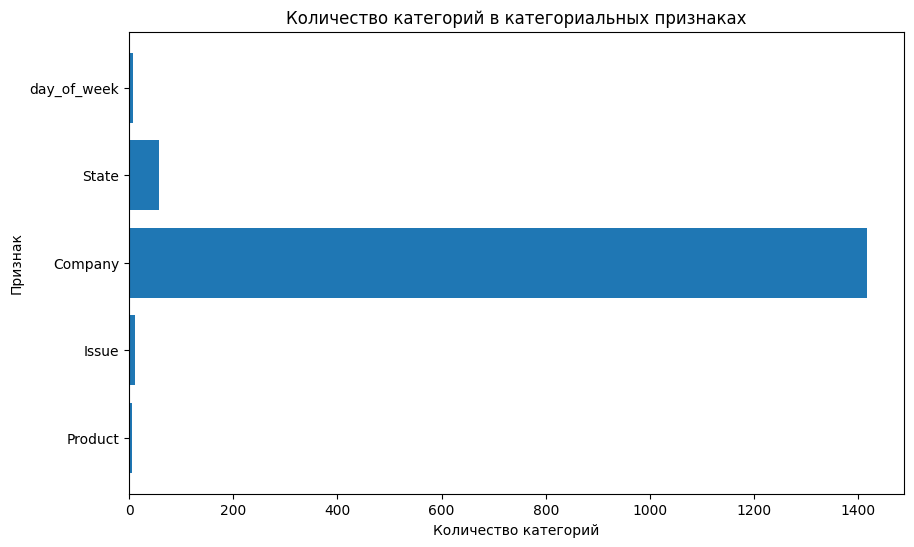

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(cat_info_table['Column'], cat_info_table['Unique values'])
plt.title('Количество категорий в категориальных признаках')
plt.xlabel('Количество категорий')
plt.ylabel('Признак')
plt.show()

Для анализа используется датасет, содержащий 53 898 обращений клиентов к финансовым организациям, другими словами, жалобы. Каждая запись включает информацию о типе финансового продукта, характере проблемы, компании, регионе клиента, времени подачи обращения и характеристиках текста жалобы.

Наибольшее количество уникальных значений содержится в признаке Company, что говорит о широком охвате финансовых организаций при анализе.

2. Посчитаем количество объектов для каждого класса по целевой переменной

In [9]:
df['Risk'].value_counts()

,count
Risk,
0,42078
1,11820


In [10]:
risk_table = df['Risk'].value_counts().reset_index()
risk_table.columns = ['Risk', 'Count']
risk_table['Percent'] = risk_table['Count'] / risk_table['Count'].sum() * 100
risk_table

,Risk,Count,Percent
0,0,42078,78.069687
1,1,11820,21.930313


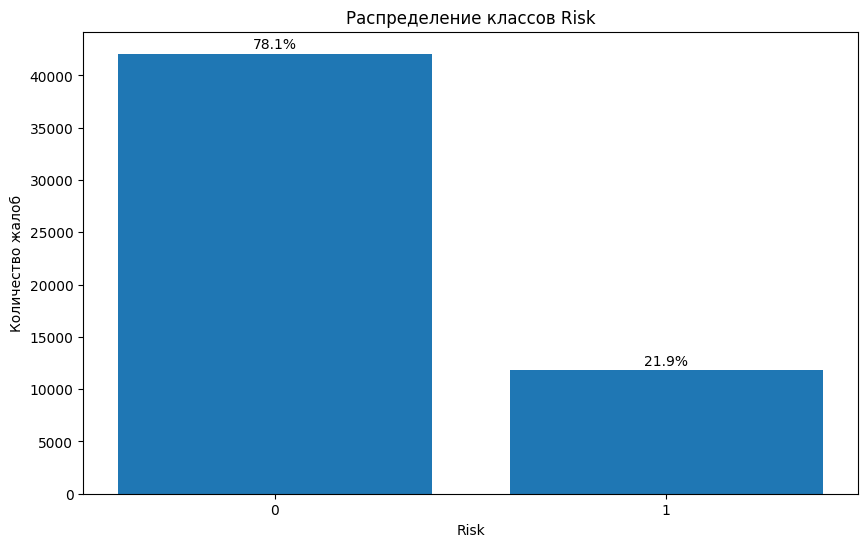

In [11]:
plt.figure(figsize=(10, 6))
plt.bar(risk_table['Risk'].astype(str), risk_table['Count'])
for i in range(len(risk_table)):
    plt.text(i, risk_table['Count'][i] + 500, str(round(risk_table['Percent'][i], 1)) + '%', ha = 'center')

plt.title('Распределение классов Risk')
plt.xlabel('Risk')
plt.ylabel('Количество жалоб')
plt.show()

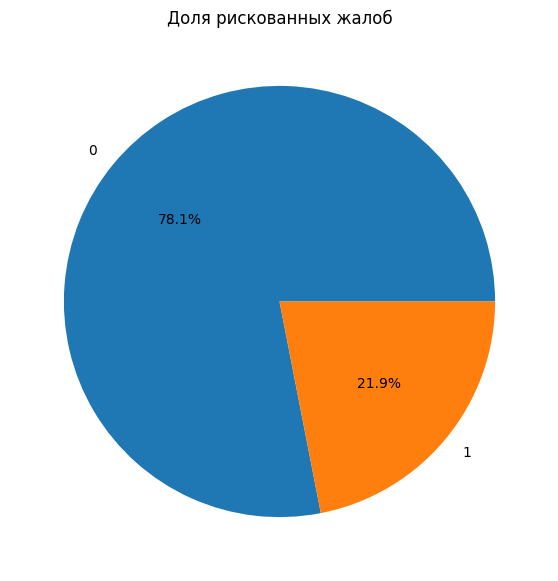

In [12]:
plt.figure(figsize=(7, 7))
plt.pie(risk_table['Count'], labels=risk_table['Risk'], autopct='%1.1f%%')
plt.title('Доля рискованных жалоб')
plt.show()

Анализ целевой переменной показавыет, что примерно 22% обращений относятся к категории повышенного риска, а оставшиеся 78% составляют обращения низкого риска.

Таким образом, примерно каждое пятое обращение требует повышенного внимания. Отметим, что объем рискованных обращений остается достаточно большим для последующего обучения модели прогнозирования риска.

3. Считаем количество жалоб по продуктам

In [13]:
product_count = df['Product'].value_counts().reset_index()
product_count.columns = ['Product', 'Count']
product_count

,Product,Count
0,Debt collection,23143
1,Checking or savings account,11671
2,Credit card,11373
3,"Money transfer, virtual currency, or money ser...",4998
4,Credit reporting or other personal consumer re...,2713


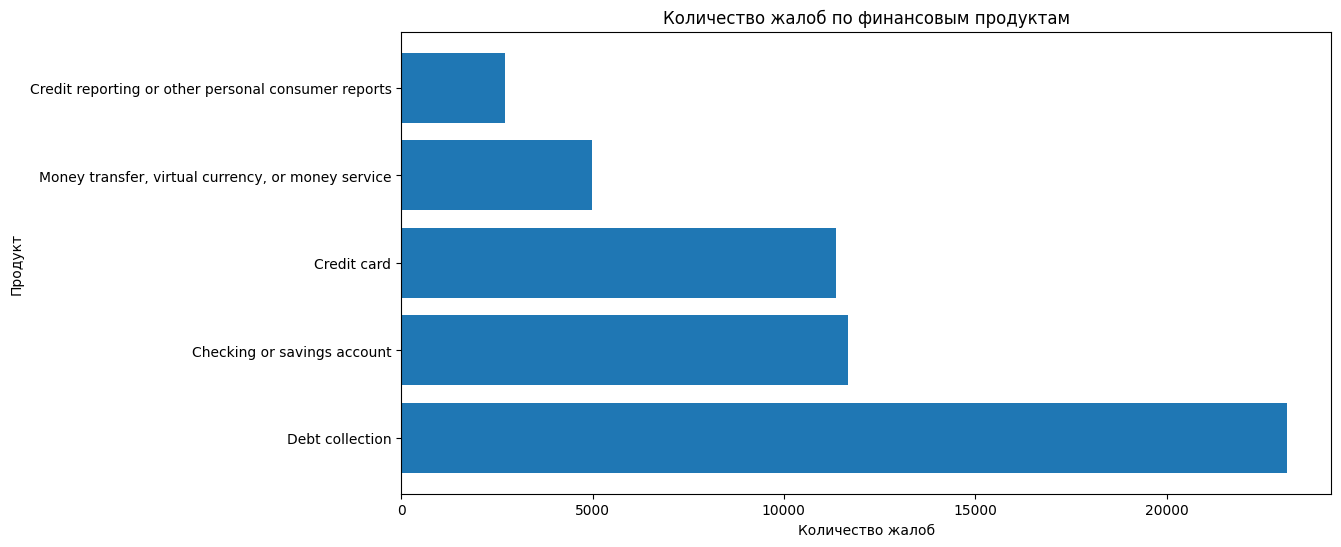

In [14]:
plt.figure(figsize=(12, 6))
plt.barh(product_count['Product'],product_count['Count'])

plt.title('Количество жалоб по финансовым продуктам')
plt.xlabel('Количество жалоб')
plt.ylabel('Продукт')
plt.show()

Считаем вероятность риска (доля Risk=1 внутри каждого продукта)

In [15]:
product_risk = df.groupby('Product')['Risk'].mean().reset_index()
product_risk['Risk'] = product_risk['Risk'] * 100
product_risk = product_risk.sort_values('Risk')

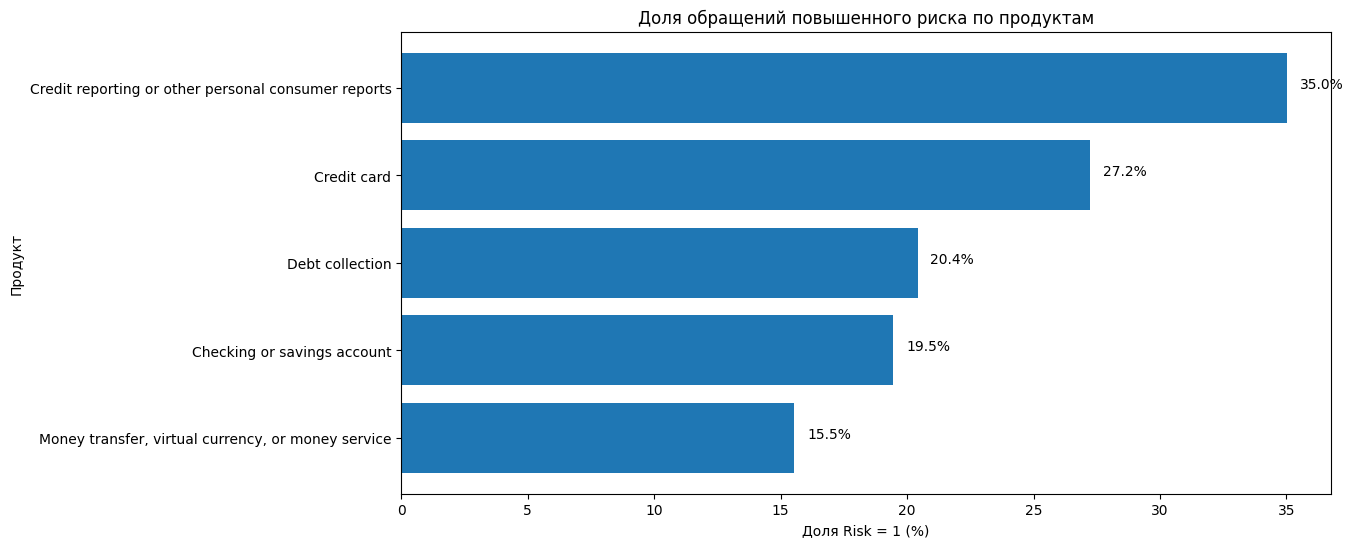

In [16]:
plt.figure(figsize=(12, 6))
plt.barh(product_risk['Product'] ,product_risk['Risk'])
for i in range(len(product_risk)):
    plt.text(product_risk['Risk'].iloc[i] + 0.5, i, str(round(product_risk['Risk'].iloc[i], 1)) + '%')

plt.title('Доля обращений повышенного риска по продуктам')
plt.xlabel('Доля Risk = 1 (%)')
plt.ylabel('Продукт')
plt.show()

Покажем одновременно: количество жалоб и долю риска.

In [17]:
product_summary = df.groupby('Product').agg({'Risk': 'mean'})
product_summary['Count'] = df['Product'].value_counts()
product_summary['Risk'] = product_summary['Risk'] * 100
product_summary = product_summary.reset_index()

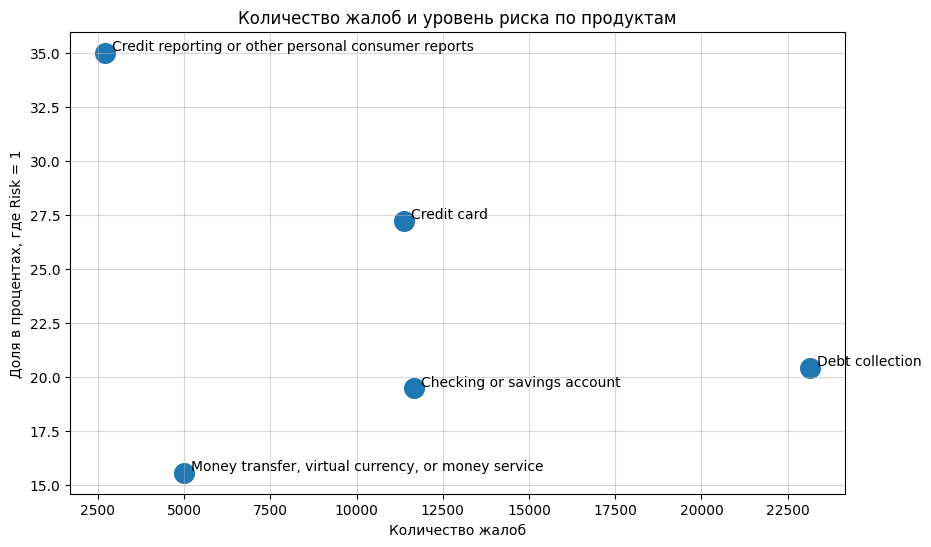

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(product_summary['Count'], product_summary['Risk'], s=200)
for i in range(len(product_summary)):
    plt.text(product_summary['Count'].iloc[i] + 200, product_summary['Risk'].iloc[i] + 0.1, product_summary['Product'].iloc[i])

plt.grid(alpha=0.5)
plt.title('Количество жалоб и уровень риска по продуктам')
plt.xlabel('Количество жалоб')
plt.ylabel('Доля в процентах, где Risk = 1')
plt.show()

Финансовые продукты демонстрируют различный уровень риска обращений. Наиболее рискованными являются продукты, связанные с кредитной отчетностью и кредитными картами, в свою очередь денежные переводы характеризуются более низкой долей обращений повышенного риска.

Это позволяет выделить направления, требующие приоритетного внимания при анализе и обработке клиентских жалоб.

4. Распределение жалоб по типам проблем

In [27]:
issue_count = df['Issue'].value_counts().reset_index()
issue_count.columns = ['Issue', 'Count']
issue_count

,Issue,Count
0,Other,15362
1,Attempts to collect debt not owed,12106
2,Managing an account,6592
3,Written notification about debt,3973
4,Problem with a purchase shown on your statement,3915
5,False statements or representation,3119
6,Took or threatened to take negative or legal a...,2049
7,Incorrect information on your report,1911
8,Problem with a lender or other company chargin...,1748
9,Closing an account,1597


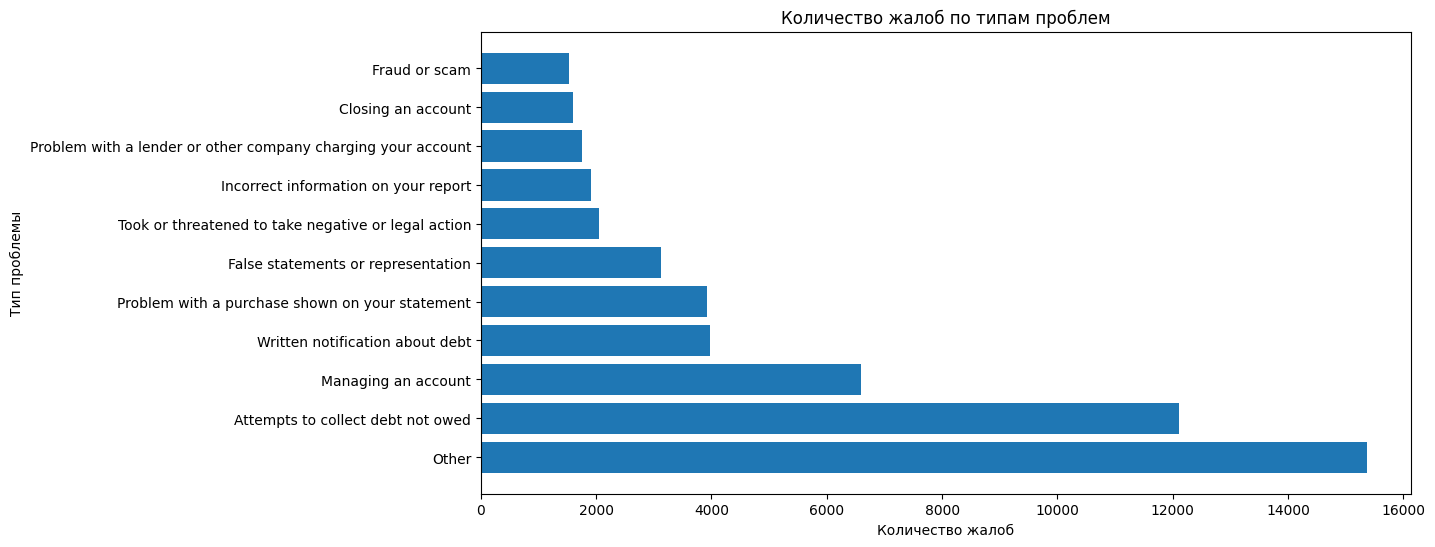

In [29]:
plt.figure(figsize=(12, 6))
plt.barh(issue_count['Issue'],issue_count['Count'])

plt.title('Количество жалоб по типам проблем')
plt.xlabel('Количество жалоб')
plt.ylabel('Тип проблемы')
plt.show()

Доля риска по проблемам (при Risk = 1)

In [30]:
issue_risk = df.groupby('Issue')['Risk'].mean().reset_index()
issue_risk['Risk'] = issue_risk['Risk'] * 100
issue_risk = issue_risk.sort_values('Risk')

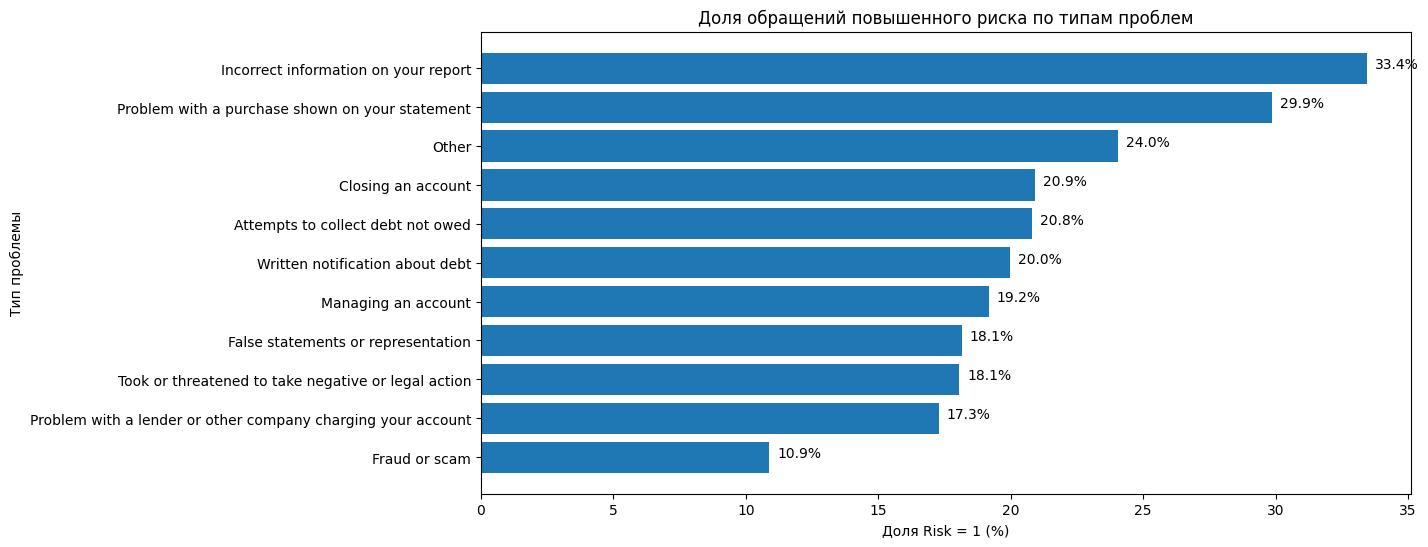

In [35]:
plt.figure(figsize=(12, 6))
plt.barh(issue_risk['Issue'],issue_risk['Risk'])

for i in range(len(issue_risk)):
  plt.text(issue_risk['Risk'].iloc[i] + 0.3, i, str(round(issue_risk['Risk'].iloc[i], 1)) + '%')

plt.title('Доля обращений повышенного риска по типам проблем')
plt.xlabel('Доля Risk = 1 (%)')
plt.ylabel('Тип проблемы')
plt.show()

Попробуем снова построить матрицу:
по оси X — количество жалоб;
по оси Y — доля риска.

In [33]:
issue_summary = df.groupby('Issue').agg({'Risk': 'mean'})
issue_summary['Count'] = df['Issue'].value_counts()
issue_summary['Risk'] = issue_summary['Risk'] * 100
issue_summary = issue_summary.reset_index()
x_mean = issue_summary['Count'].mean()
y_mean = issue_summary['Risk'].mean()

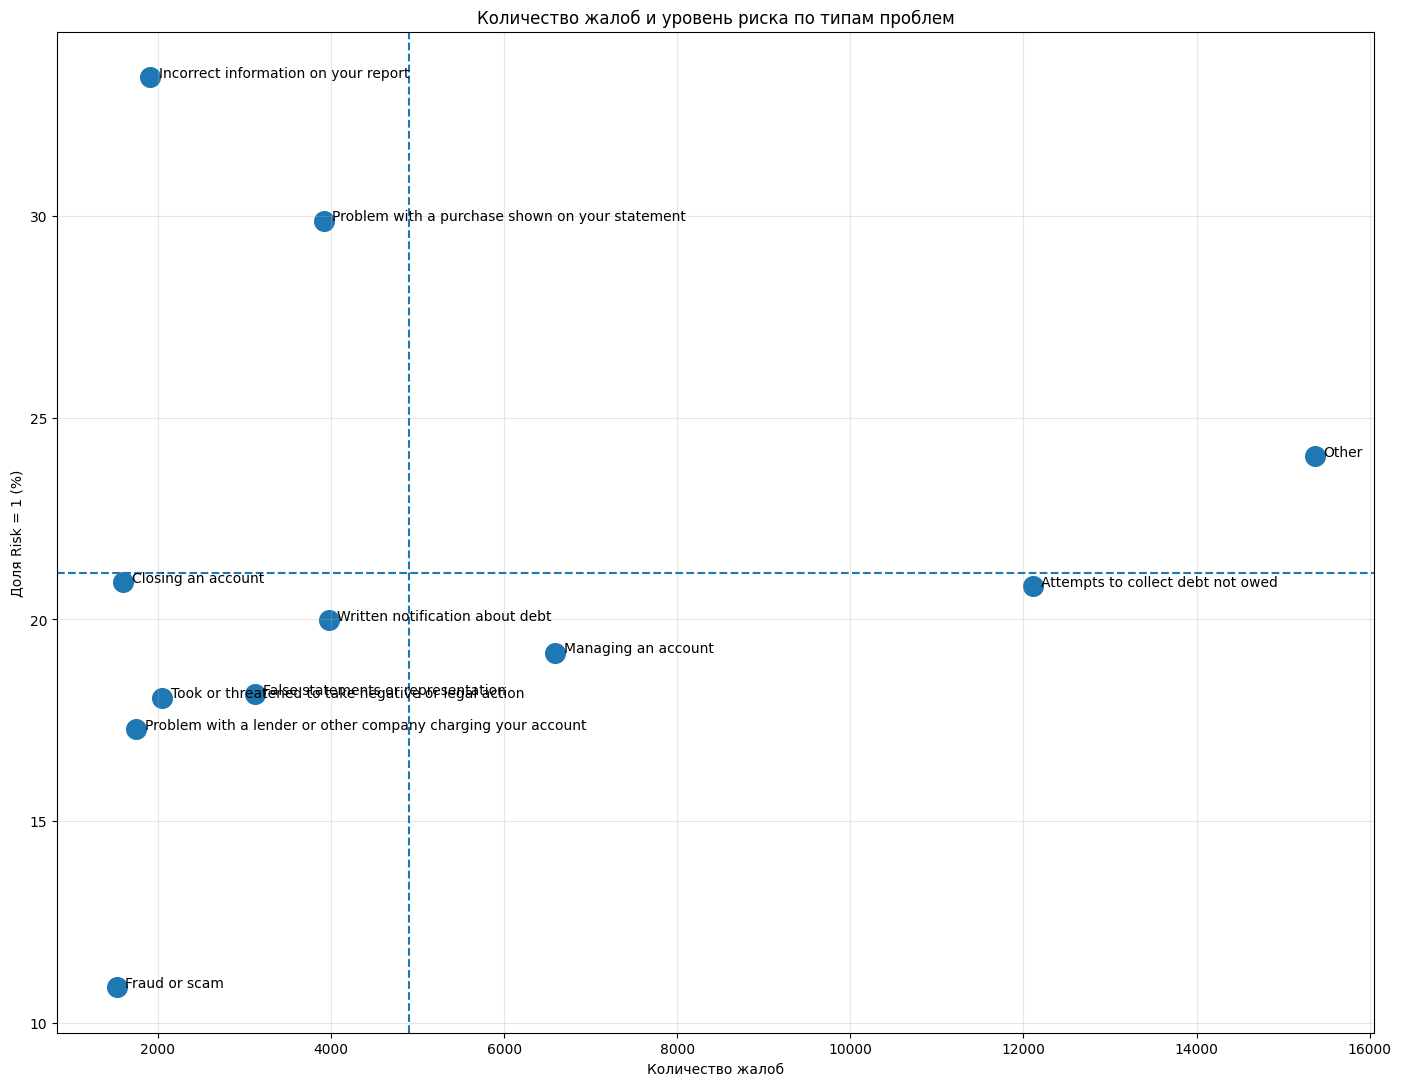

In [50]:
plt.figure(figsize=(17, 13))
plt.scatter(issue_summary['Count'], issue_summary['Risk'], s=200)

for i in range(len(issue_summary)):
    plt.text(issue_summary['Count'].iloc[i] + 100, issue_summary['Risk'].iloc[i], issue_summary['Issue'].iloc[i])


plt.axvline(x_mean, linestyle='--')
plt.axhline(y_mean, linestyle='--')

plt.grid(alpha=0.3)
plt.title('Количество жалоб и уровень риска по типам проблем')
plt.xlabel('Количество жалоб')
plt.ylabel('Доля Risk = 1 (%)')
plt.show()

**Горизонтальная пунктирная линия** показывает: Средний уровень риска по всем типам проблем.

**Вертикальная пунктирная линия** показывает: Среднее количество жалоб по всем типам проблем.

**Из-за этого образуются четыре зоны.**

Правый верхний квадрант
Много жалоб
+
Высокий риск
Самая важная зона. Это основные источники бизнес-риска.

Левый верхний квадрант
Мало жалоб
+
Высокий риск
Редкие, но потенциально критичные проблемы.

Правый нижний квадрант
Много жалоб
+
Низкий риск
Массовые проблемы, которые возникают часто, но реже приводят к серьезным последствиям.

Левый нижний квадрант
Мало жалоб
+
Низкий риск
Наименее приоритетная зона.

Наибольший интерес представляют проблемы, расположенные в правом верхнем квадрате, так как они сочетают высокий уровень риска с большим количеством жалоб. Именно эти категории могут рассматриваться как приоритетные направления для дальнейшего анализа и совершенствования процессов работы с клиентскими обращениями.

5. Связь Product и Issue - какие продукты более рискованные; какие проблемы более рискованные.

In [51]:
product_issue = pd.crosstab(df['Product'], df['Issue'])
product_issue

Issue,Attempts to collect debt not owed,Closing an account,False statements or representation,Fraud or scam,Incorrect information on your report,Managing an account,Other,Problem with a lender or other company charging your account,Problem with a purchase shown on your statement,Took or threatened to take negative or legal action,Written notification about debt
Product,,,,,,,,,,,
Checking or savings account,0,1597,0,0,30,6592,1704,1748,0,0,0
Credit card,0,0,0,0,475,0,6983,0,3915,0,0
Credit reporting or other personal consumer reports,0,0,0,0,1406,0,1307,0,0,0,0
Debt collection,12106,0,3119,0,0,0,1896,0,0,2049,3973
"Money transfer, virtual currency, or money service",0,0,0,1526,0,0,3472,0,0,0,0


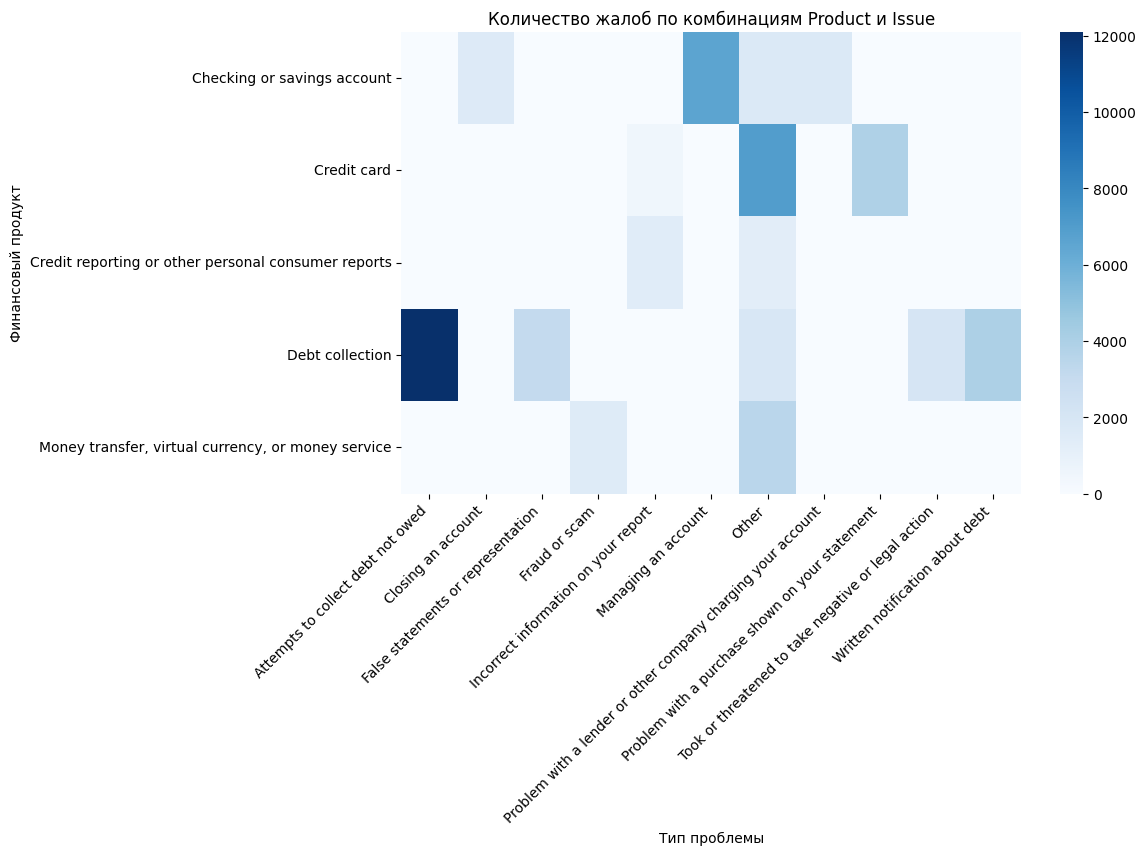

In [60]:
plt.figure(figsize=(10, 6))
sns.heatmap(product_issue, cmap='Blues')

plt.title('Количество жалоб по комбинациям Product и Issue')
plt.xlabel('Тип проблемы')
plt.ylabel('Финансовый продукт')
plt.xticks(rotation=45, ha='right')
plt.show()

Считаем средний риск для каждой комбинации (Product × Issue × Risk)

In [62]:
product_issue_risk = df.groupby(['Product', 'Issue'])['Risk'].mean().reset_index()
product_issue_risk['Risk'] = product_issue_risk['Risk'] * 100

In [63]:
product_issue_risk = product_issue_risk.pivot(index='Product', columns='Issue', values='Risk')

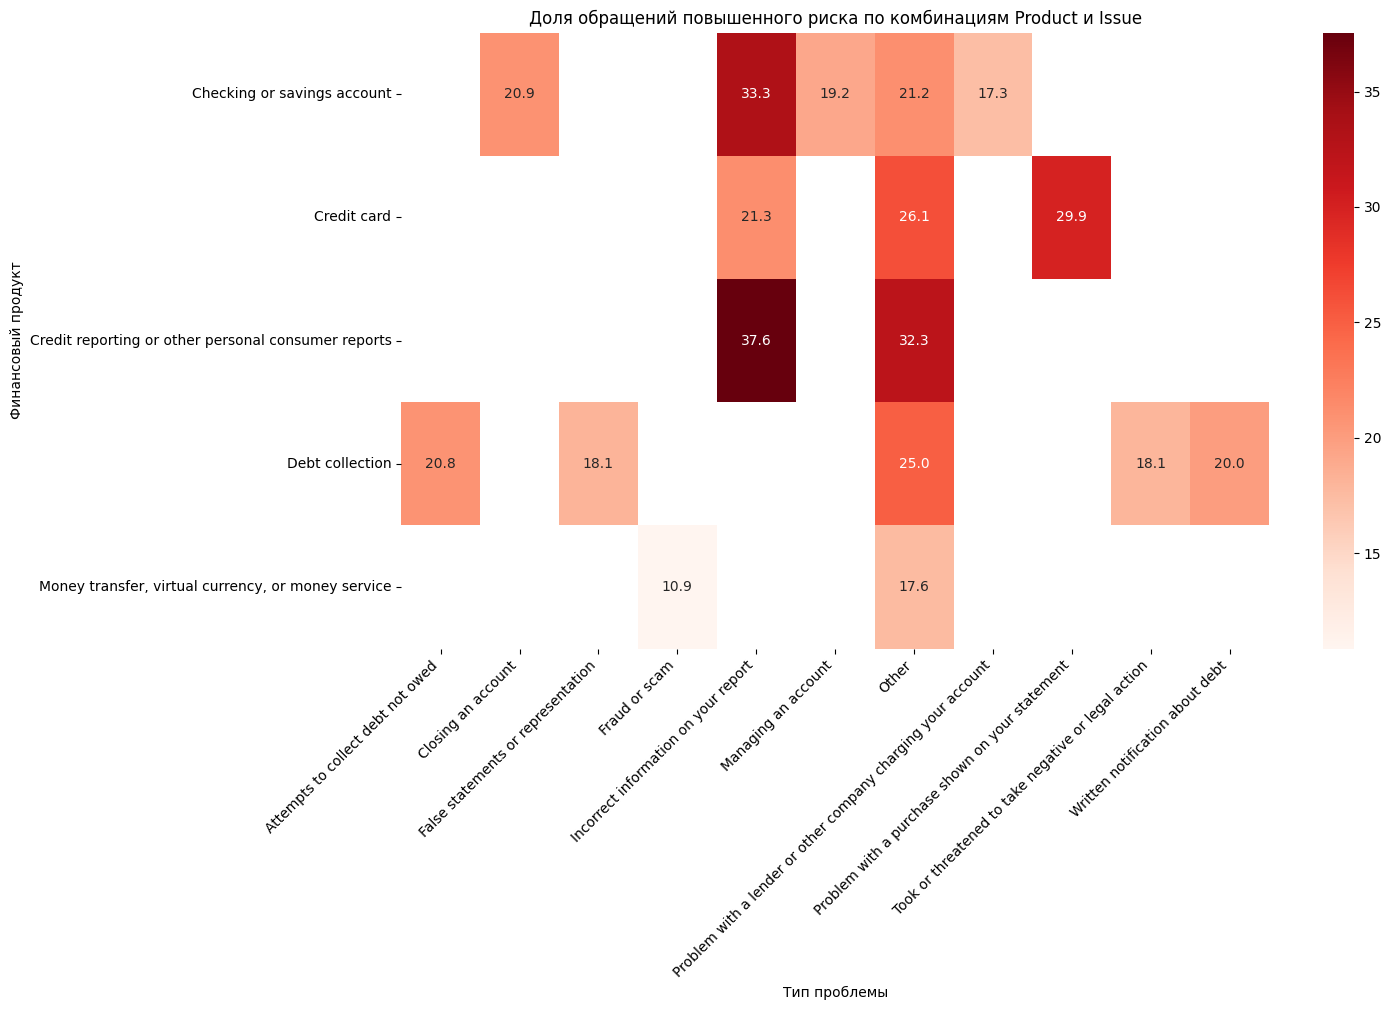

In [65]:
plt.figure(figsize=(14, 8))
sns.heatmap(product_issue_risk, annot=True, fmt='.1f', cmap='Reds')

plt.title('Доля обращений повышенного риска по комбинациям Product и Issue')
plt.xlabel('Тип проблемы')
plt.ylabel('Финансовый продукт')
plt.xticks(rotation=45, ha='right')
plt.show()

То есть мы имеем в виду, что уровень риска определяется не только самим продуктом или проблемой по отдельности, а их сочетанием. Для ряда комбинаций наблюдается существенно более высокая доля обращений повышенного риска по сравнению со средним уровнем по данным.

Это наблюдение позволяет определить наиболее проблемные сценарии взаимодействия клиентов с финансовыми организациями, чтобы выбрать приоритетные направления для анализа.

Перейдем к портрету рискованной жалобы

Попробуем определить чем отличается рискованная жалоба от обычной?

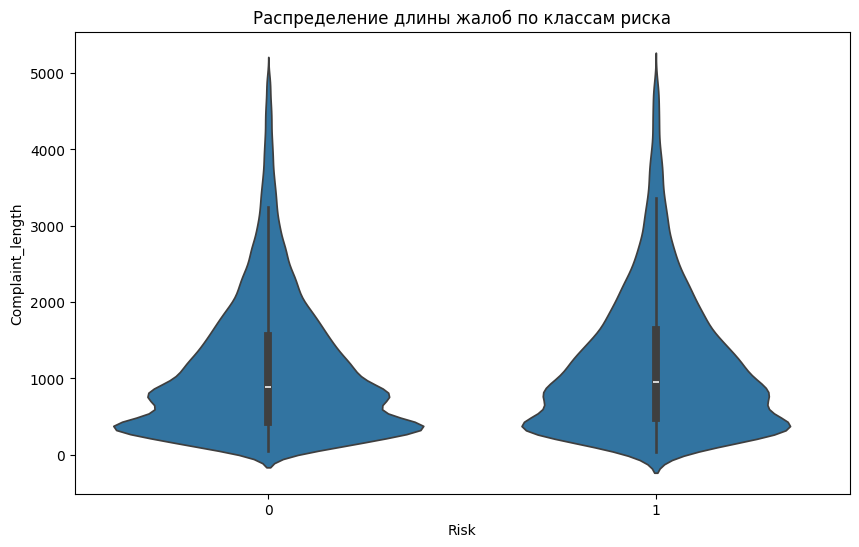

In [69]:
a = df[df['Complaint_length'] < 5000]
plt.figure(figsize=(10, 6))

sns.violinplot(data=a, x='Risk', y='Complaint_length')
plt.title('Распределение длины жалоб по классам риска')
plt.xlabel('Risk')
plt.ylabel('Complaint_length')
plt.show()

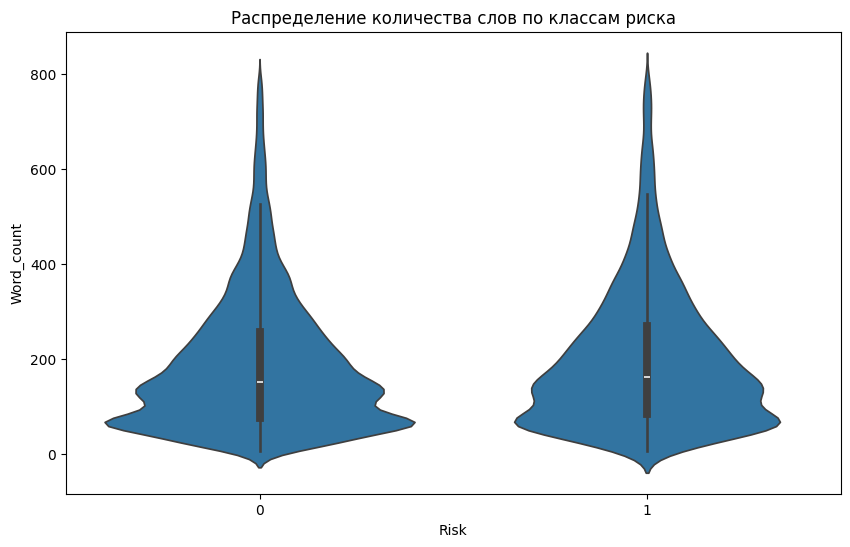

In [72]:
a = df[df['Word_count'] < 800]
plt.figure(figsize=(10, 6))
sns.violinplot(data=a, x='Risk', y='Word_count')

plt.title('Распределение количества слов по классам риска')
plt.xlabel('Risk')
plt.ylabel('Word_count')
plt.show()

In [73]:
length_stats = df.groupby('Risk')[['Complaint_length', 'Word_count']].mean()
length_stats

,Complaint_length,Word_count
Risk,,
0,1219.305884,202.717144
1,1288.866920,215.261421


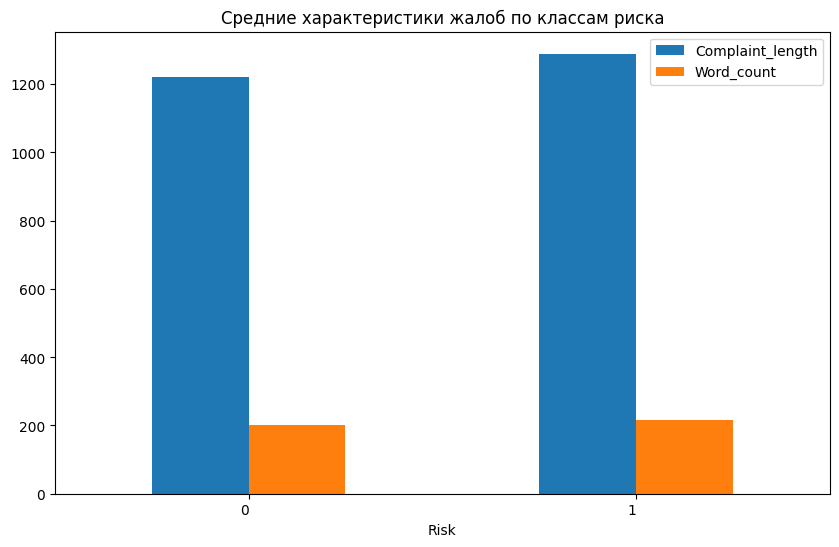

In [78]:
length_stats.plot(kind='bar',figsize=(10, 6))
plt.title('Средние характеристики жалоб по классам риска')
plt.xticks(rotation=0, ha='right')
plt.show()

Анализ текстовых характеристик обращений показал, что жалобы повышенного риска отличаются от обычных не только содержанием, но и объемом текста. В среднем рискованные обращения содержат более подробное описание проблемы, что может говорить о повышенной сложности рассматриваемых случаев и большем уровне вовлеченности клиента в процесс подачи жалобы.

7. Когда возникают рискованные обращения

Здесь мы анализируем:
hour
day_of_week
month

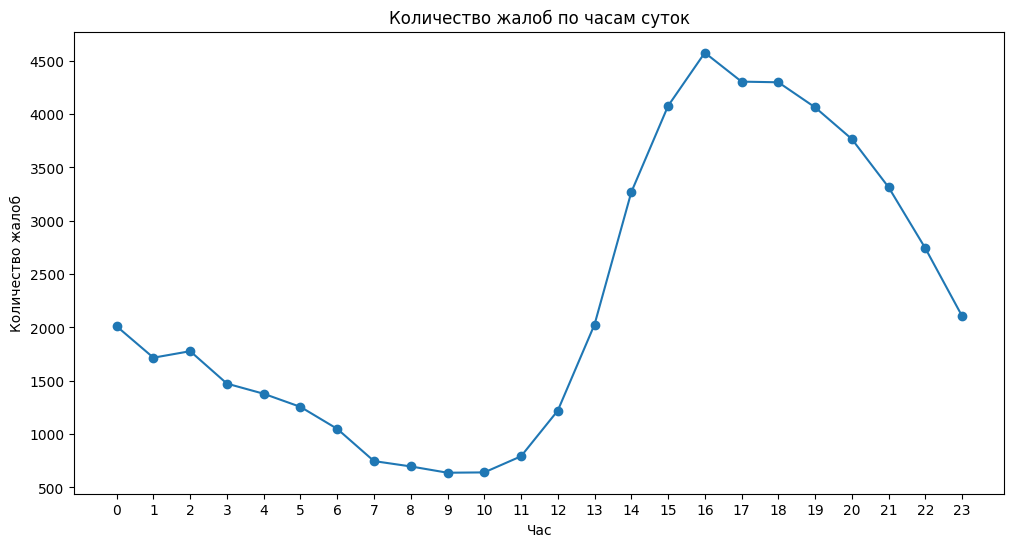

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(hour_count.index, hour_count.values, marker='o')

plt.title('Количество жалоб по часам суток')
plt.xlabel('Час')
plt.ylabel('Количество жалоб')
plt.xticks(range(24))
plt.show()

In [84]:
hour_risk = df.groupby('hour')['Risk'].mean() * 100

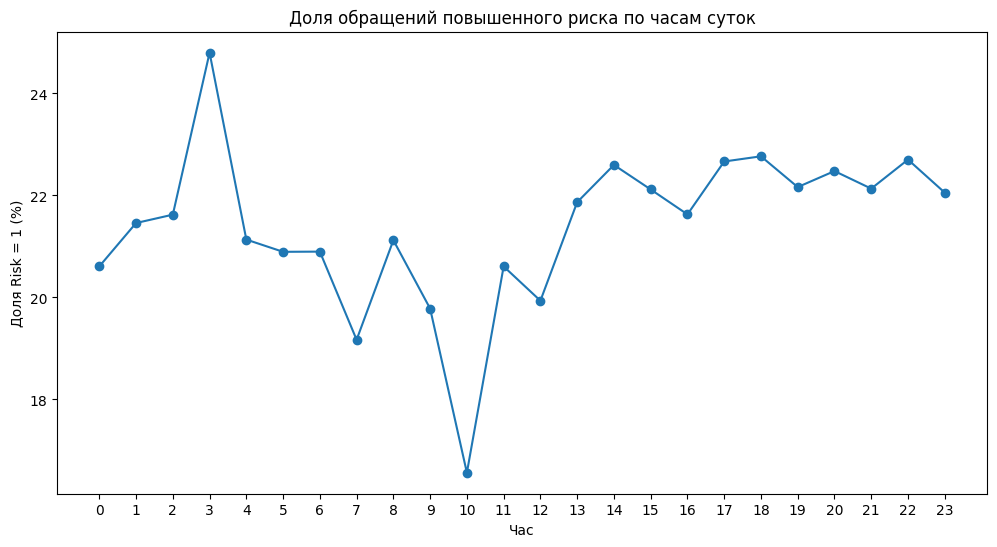

In [85]:
plt.figure(figsize=(12, 6))
plt.plot(hour_risk.index, hour_risk.values, marker='o')

plt.title('Доля обращений повышенного риска по часам суток')
plt.xlabel('Час')
plt.ylabel('Доля Risk = 1 (%)')
plt.xticks(range(24))
plt.show()

In [86]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [87]:
day_count = df['day_of_week'].value_counts()
day_count = day_count.reindex(days)

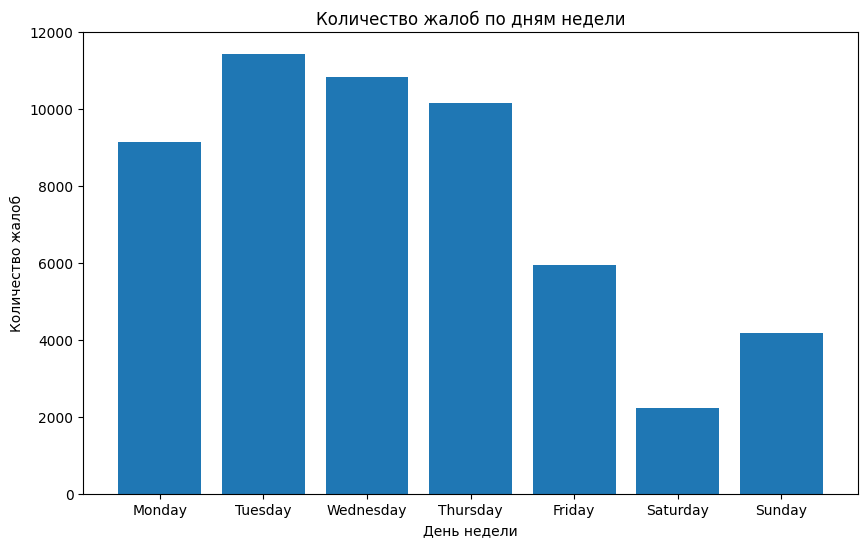

In [88]:
plt.figure(figsize=(10, 6))
plt.bar(day_count.index, day_count.values)

plt.title('Количество жалоб по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество жалоб')
plt.show()

In [90]:
day_risk = df.groupby('day_of_week')['Risk'].mean() * 100
day_risk = day_risk.reindex(days)

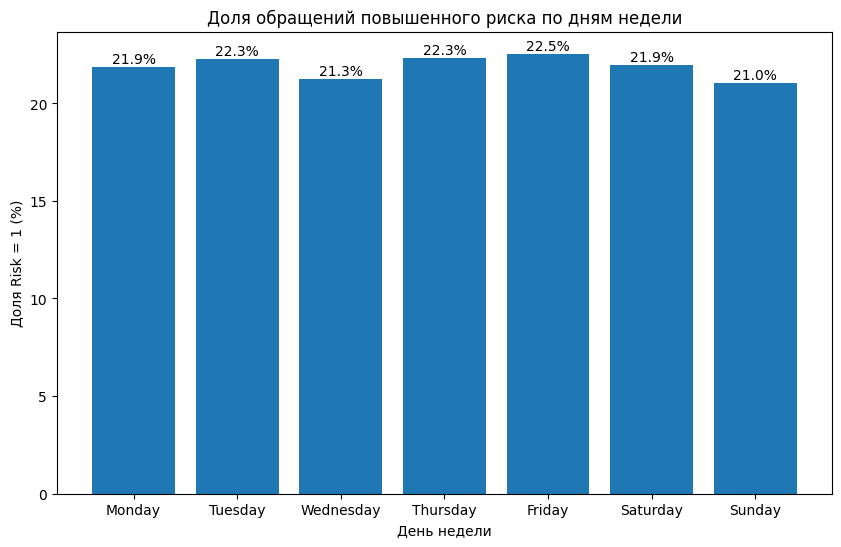

In [91]:
plt.figure(figsize=(10, 6))
plt.bar(day_risk.index, day_risk.values)
for i in range(len(day_risk)):
    plt.text(i, day_risk.iloc[i] + 0.2, str(round(day_risk.iloc[i], 1)) + '%', ha='center')

plt.title('Доля обращений повышенного риска по дням недели')
plt.xlabel('День недели')
plt.ylabel('Доля Risk = 1 (%)')
plt.show()

In [92]:
month_count = df['month'].value_counts().sort_index()

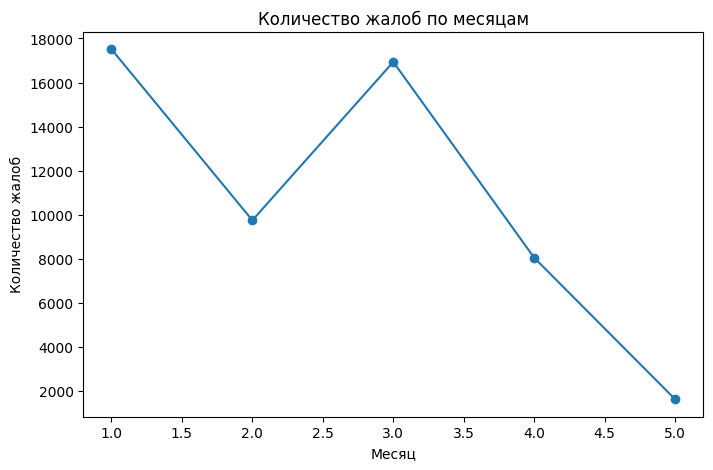

In [93]:
plt.figure(figsize=(8, 5))
plt.plot(month_count.index, month_count.values, marker='o')

plt.title('Количество жалоб по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество жалоб')
plt.show()

In [94]:
month_risk = df.groupby('month')['Risk'].mean() * 100

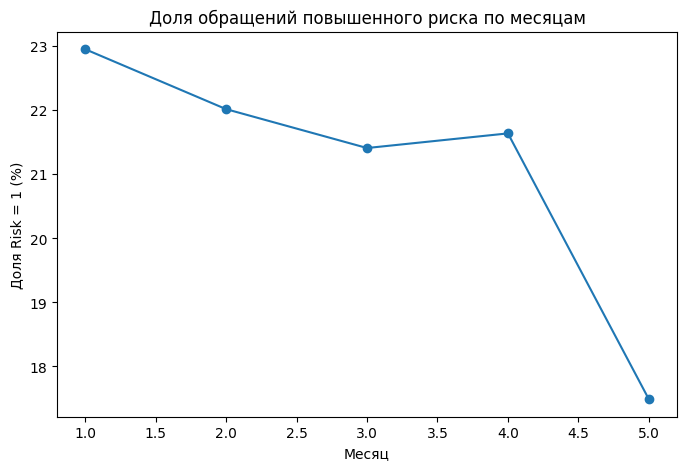

In [95]:
plt.figure(figsize=(8, 5))
plt.plot(month_risk.index, month_risk.values, marker='o')

plt.title('Доля обращений повышенного риска по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Доля Risk = 1 (%)')
plt.show()

In [96]:
hour_day = pd.pivot_table(df, values='Risk', index='day_of_week', columns='hour', aggfunc='mean')
hour_day = hour_day.reindex(days)

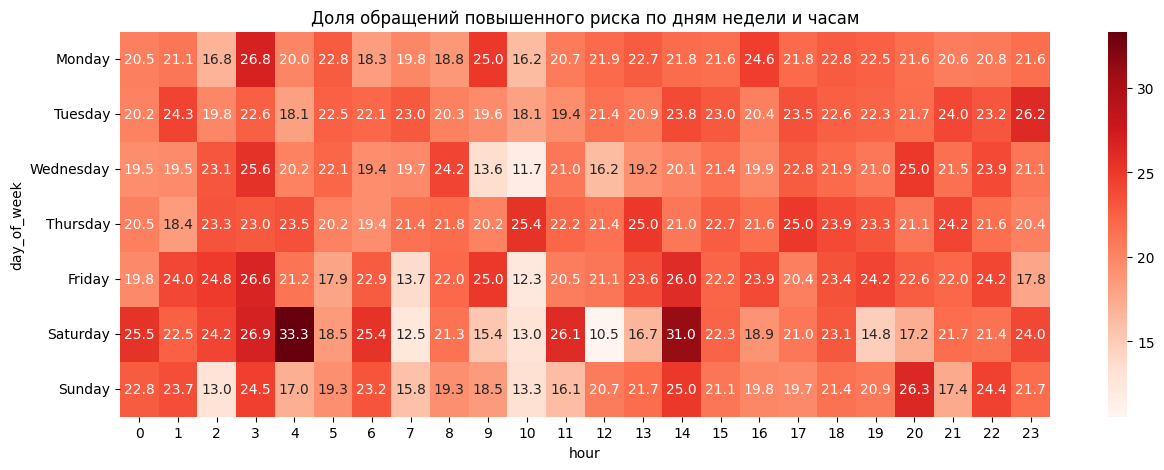

In [99]:
plt.figure(figsize=(15, 5))
sns.heatmap(hour_day * 100, annot=True, fmt='.1f', cmap='Reds')

plt.title('Доля обращений повышенного риска по дням недели и часам')
plt.show()